In [1]:
import os, warnings
import numpy as np
import time

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import pickle
import os
import warnings
warnings.filterwarnings("ignore")

import sys
CUDA_VISIBLE_DEVICES=""
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
sys.path.insert(0,'../../uqmodels/abench')
sys.path.insert(0,'../../n5_uqmodels/')
sys.path.insert(0,'src/')
import abench
import uqmodels
import yaml

In [2]:
import yaml
config_benchmark_path = "config/config_benchmark.yaml"
with open(config_benchmark_path) as f:
    config_benchmark = yaml.safe_load(f)
print(config_benchmark['validation_config'])

{'Random_pos_offset_low': {'constraint_selection': [['dataset', ['new_dataset10_random_pos_offset_low']]], 'constraint_rejection': []}, 'Random_pos_offset_median': {'constraint_selection': [['dataset', ['new_dataset10_random_pos_offset_median']]], 'constraint_rejection': []}, 'Random_pos_offset_high': {'constraint_selection': [['dataset', ['new_dataset10_random_pos_offset_high']]], 'constraint_rejection': []}}


In [4]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

2026-01-29 11:05:35.728334: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-29 11:05:35.855583: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-29 11:05:35.859392: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-01-29 11:05:35.859408: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not ha

[]


2026-01-29 11:05:38.507068: E tensorflow/stream_executor/cuda/cuda_driver.cc:265] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-01-29 11:05:38.507094: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:169] retrieving CUDA diagnostic information for host: HP-5CD3482FLZ.irt-systemx.local
2026-01-29 11:05:38.507098: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:176] hostname: HP-5CD3482FLZ.irt-systemx.local
2026-01-29 11:05:38.507188: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:200] libcuda reported version is: 550.163.1
2026-01-29 11:05:38.507206: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:204] kernel reported version is: NOT_FOUND: could not find kernel module information in driver version file contents: "NVRM version: NVIDIA UNIX Open Kernel Module for x86_64  550.163.01  Release Build  (dvs-builder@U16-I3-E02-3-2)  Tue Apr  8 12:25:33 UTC 2025
GCC version:  gcc version 12.3.0 (Ubuntu 12.3.0-1ubuntu1~22.04.2) 
"


In [ ]:
# Specification of Data :
from abench.data_loader.timeseries.data_loader import ABLoaderFromSequenceFolder,ABLosoDataExperiment
from abench.data_loader.timeseries.scaler import TemporalFeatureScaler

datasets = ['new_dataset10']
# validation_config = {'Noisy': {'constraint_selection': [['dataset', ['dataset1']]], 'constraint_rejection': []}}
sets_norm_scale = ['set_0', 'set_1','set_2', 'set_3', 'set_4']
sets_cv_exp =['set_0', 'set_1','set_2', 'set_3', 'set_4']
validation_config = config_benchmark['validation_config']
# sets_norm_scale = []
# sets_cv_exp =[]
Components_config = {'DenseVAE': 'config/config_vae.yaml', 'ConvVAE': 'config/config_vae.yaml', 'TimeVAE': 'config/config_vae.yaml'}


# Exemple of a dataloder that provide (X,y),Context,metadata related to a selection
Dataloader_Train = ABLoaderFromSequenceFolder(path='data/',
                           depth_name_list = ['dataset','set'],
                           constraint_selection_list = [('dataset',datasets),('set',sets_norm_scale)],
                           constraint_rejection_list = [],
                           w_size=50,
                           sampling=1, 
                           sample_stride=50,
                           horizon_start=0,
                           prediction_number=50,
                           y_step=1,
                           x_features= ['positionX', 'positionY', 'VelX', 'VelY'],
                           y_features = ['positionX', 'positionY', 'VelX','VelY'],
                        #    context_features = ['Id', 'timestamp', 'positionX', 'positionY', 'positionZ', 'sizeX','sizeY', 'sizeZ', 'VelX', 'VelY', 'VelZ', 'Vel', 'Class', 'rot_x',
                        #                        'rot_y', 'edge', 'ts', 'departure', 'destination', 'dataset', 'set','filename', 'seqId', 'length', 'cat_length', 'cat_edge'],
                           context_features = ['Id', 'timestamp', 'positionX', 'positionY', 'positionZ', 'sizeX','sizeY', 'sizeZ', 'VelX', 'VelY', 'VelZ', 'Vel', 'Class', 'rot_x',
                                               'rot_y', 'edge', 'ts', 'departure', 'destination', 'dataset', 'set','filename']
                           ,with_context=True,
                           with_metadata=True,
                           Xscaler = TemporalFeatureScaler(),
                           Yscaler = TemporalFeatureScaler(),
                           shuffle=False,
                           name='set_2&3',
                           dir_cache=None)

for (X,y),context,metadata in Dataloader_Train:
    pass

Xscaler_train = Dataloader_Train.Xscaler
Yscaler_train = Dataloader_Train.Yscaler

ABloader_dict_params = {'path':'data/','depth_name_list':['dataset','set'],
                        'constraint_selection_list':[],
                        'constraint_rejection_list':[],
                        'w_size':50,'sampling':1,'sample_stride':50,'horizon_start':0,'prediction_number':50,'y_step':1,
                        'x_features':['positionX', 'positionY', 'VelX', 'VelY'],
                        'y_features':['positionX', 'positionY', 'VelX','VelY'],
                        # 'context_features':['Id', 'timestamp', 'positionX', 'positionY', 'positionZ', 'sizeX','sizeY', 'sizeZ', 'VelX', 'VelY', 'VelZ', 'Vel', 'Class', 'rot_x',
                        #                        'rot_y', 'edge', 'ts', 'departure', 'destination', 'dataset', 'set','filename', 'seqId', 'length', 'cat_length', 'cat_edge'],
                        'context_features' : ['Id', 'timestamp', 'positionX', 'positionY', 'positionZ', 'sizeX','sizeY', 'sizeZ', 'VelX', 'VelY', 'VelZ', 'Vel', 'Class', 'rot_x',
                                               'rot_y', 'edge', 'ts', 'departure', 'destination', 'dataset', 'set','filename'],
                        'with_context':True,'with_metadata':True,
                        'Xscaler':Xscaler_train, 'Yscaler':Yscaler_train,
                        'name':'data'}

# DataExperimentPlan : Cross validation 
DataExperiment = ABLosoDataExperiment(ABLoaderFromSequenceFolder,ABloader_dict_params,depth_name='set',subjet_ids=sets_norm_scale,validation_config=validation_config)
DataExperiment.check_set_names()

100%|██████████| 25/25 [00:02<00:00, 11.81it/s]


set_0
set_1
set_2
set_3
set_4
Train data_Train_LOSO_set_0
Test data_Test_LOSO_set_0
Train data_Train_LOSO_set_1
Test data_Test_LOSO_set_1
Train data_Train_LOSO_set_2
Test data_Test_LOSO_set_2
Train data_Train_LOSO_set_3
Test data_Test_LOSO_set_3
Train data_Train_LOSO_set_4
Test data_Test_LOSO_set_4


In [ ]:
# Specification of Data :
from abench.data_loader.timeseries.data_loader import ABLoaderFromSequenceFolder,ABLosoDataExperiment
from abench.data_loader.timeseries.scaler import TemporalFeatureScaler

# Exemple of a dataloder that provide (X,y),Context,metadata related to a selection
Dataloader_Train = ABLoaderFromSequenceFolder(path='data/',
                           depth_name_list = ['dataset','set'],
                           constraint_selection_list = [('dataset',['dataset1']),('set',['set_0', 'set_1','set_2', 'set_3'])],
                           constraint_rejection_list = [],
                           w_size=50,
                           sampling=1, 
                           sample_stride=50,
                           horizon_start=0,
                           prediction_number=50,
                           y_step=1,
                           x_features= ['positionX', 'positionY', 'VelX', 'VelY'],
                           y_features = ['positionX', 'positionY', 'VelX','VelY'],
                           context_features = ['Id','timestamp', 'edge','ts'],
                           with_context=True,
                           with_metadata=True,
                           Xscaler=TemporalFeatureScaler(),
                           Yscaler=TemporalFeatureScaler(),
                           shuffle=False,
                           name='set_0',
                           dir_cache=None)


import tensorflow as tf
from uqmodels.modelization.TF_estimator.base.train_config import make_optimizer_default,make_callbacks
from uqmodels.modelization.TF_estimator.vae.train_config import add_vae_callbacks
from uqmodels.modelization.TF_estimator.base.loss import build_MSE_loss
import uqmodels.modelization.TF_estimator.vae.vae as vae

model_params = {'seq_len':50, 'input_dim':4, 'latent_dim':8,'name':'VAE','basic':True,'kl_weight':0.01}

training_params = {'optimizer':'nadam', 'batch_size':128, 'epochs':2}

opt = make_optimizer_default(training_params['optimizer'])
mse = build_MSE_loss(split=1,metric=False,reduce=False)
mse = None
mse_metric = build_MSE_loss(split=1,metric=True) 
default_compile_kwargs = dict(optimizer=opt,loss=mse,metrics=[mse_metric])
callbacks, configs = make_callbacks()
if('kl_weight' in training_params):
    callbacks = add_vae_callbacks(callbacks,training_params['kl_weight'])
default_fit_kwargs = dict(epochs=training_params['epochs'],batch_size=training_params['batch_size'], verbose=1,callbacks=callbacks,shuffle=True)

model_params['training_params'] = training_params
model_params['compile_kwargs']= default_compile_kwargs
model_params['fit_kwargs']= default_fit_kwargs

model = vae.DenseVAE(**model_params)

# Already done by model

for (X,y),context,metadata in Dataloader_Train:
    print('fit')
    # Already done old by BaseKModel_class using compile_kwargs and fit_kwargs
    #model.compile(optimizer = train_params['optimizer'])
    model.fit(X,y)

print('predict')
output = model.predict(X)

2026-01-29 11:13:00.210825: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


<function build_MSE_loss.<locals>.MSE_loss at 0x712dfb201a20>


100%|██████████| 1/1 [00:06<00:00,  6.08s/it]


fit
Epoch 1/2
366/366 [==============================] - 3s 6ms/step - loss: 0.2107 - reconstruction_loss: 0.1312 - kl_loss: 7.9447 - lr: 0.0010
Epoch 2/2
366/366 [==============================] - 2s 6ms/step - loss: 0.1200 - reconstruction_loss: 0.0495 - kl_loss: 7.0528 - lr: 0.0010
predict


In [9]:
 model.fit(X,y)

Epoch 1/2
366/366 [==============================] - 2s 6ms/step - loss: 0.1076 - reconstruction_loss: 0.0428 - kl_loss: 6.4801 - lr: 0.0010
Epoch 2/2
366/366 [==============================] - 2s 7ms/step - loss: 0.1006 - reconstruction_loss: 0.0392 - kl_loss: 6.1398 - lr: 0.0010


In [8]:
model.summary()


Encoder:
Model: "encoder_dense"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 encoder_input (InputLayer)     [(None, 50, 4)]      0           []                               
                                                                                                  
 enc_flatten (Flatten)          (None, 200)          0           ['encoder_input[0][0]']          
                                                                                                  
 enc_dense_0 (Dense)            (None, 128)          25728       ['enc_flatten[0][0]']            
                                                                                                  
 enc_dense_1 (Dense)            (None, 128)          16512       ['enc_dense_0[0][0]']            
                                                                            

In [ ]:
from src.metric import base_rmse,ABMetricGeneric
AB_RMSE = ABMetricGeneric(metric=base_rmse,name="rmse", mask=None, dim_mask=None, list_ctx_constraint=None,reduce=True)

Xscaler_train = Dataloader_Train.Xscaler
Yscaler_train = Dataloader_Train.Yscaler
Dataloader_Test = ABLoaderFromSequenceFolder(path='data/',
                           depth_name_list = ['dataset','set'],
                           constraint_selection_list = [('dataset',['dataset1']),('set',['set_4'])],
                           constraint_rejection_list = [],
                           w_size=50,
                           sampling=1, 
                           sample_stride=50,
                           horizon_start=0,
                           prediction_number=50,
                           y_step=1,
                           x_features= ['positionX', 'positionY', 'VelX', 'VelY'],
                           y_features = ['positionX', 'positionY', 'VelX','VelY'],
                           context_features = ['Id','timestamp', 'edge','ts'],
                           with_context=True,
                           with_metadata=True,
                           Xscaler=Xscaler_train,
                           Yscaler=Yscaler_train,
                           shuffle=False,
                           name='set_2&3',
                           dir_cache=None)

for (X,y),context,metadata in Dataloader_Train:
    output = model.predict(X)
    print('Train:', AB_RMSE.compute(y,output,context,metadata))
for (X_test,y_test),context_test,metadata_test in Dataloader_Test:
    output_test = model.predict(X_test)
    print('Test:', AB_RMSE.compute(y_test,output_test,context_test,metadata_test))

100%|██████████| 1/1 [00:03<00:00,  3.14s/it]


Train: 0.1900546701465231


100%|██████████| 7/7 [00:15<00:00,  2.18s/it]


Test: 0.19019557361247552


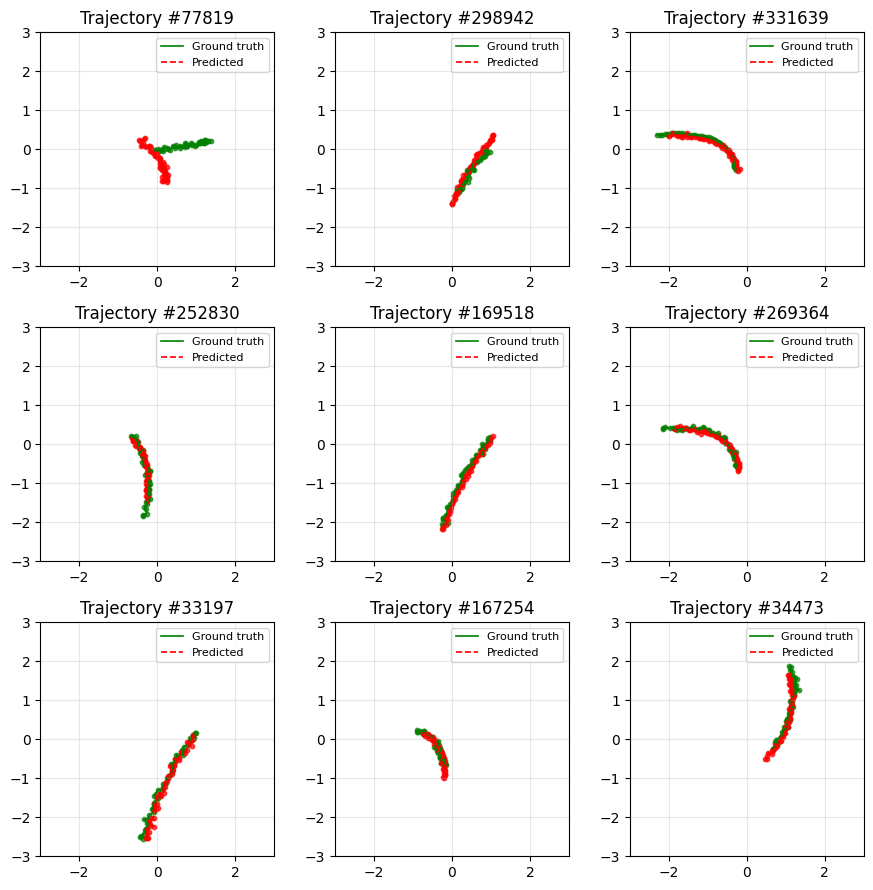

In [11]:
from src.visu import plot_trajet
from abench.visu.base import plot_grid

fig, axes, idx_used = plot_grid(
    plot_fn=plot_trajet,
    y=y_test,
    output=output_test,
    context=np.arange(len(output_test))[:,None],
    metadata=None,
    n=3,
    random_state=42,
    lim=(-3, 3),
    figsize_per_cell=3,
    title_fn=lambda i, y_i, out_i, ctx_i, meta_i: f"Trajectory #{ctx_i[0]}",
)